In [1]:
%matplotlib inline

import os
os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE" # tells OpenMP to not complain if it notices that two copies of OpenMP are loaded.

from IPython.display import Video
from IPython.display import Audio as play_audio
from torchvision.utils import make_grid
from torchcodec.encoders import VideoEncoder

def play_video(encoded_bytes):
    return Video(data=encoded_bytes.numpy().tobytes(),
                embed=True, width=640, height=360, mimetype="video/mp4")

import matplotlib.pyplot as plt

import sys
sys.path.append('../../../')

In [2]:
import os
import warnings
from pathlib import Path
from typing import Any, Callable, Optional, Union, cast

import torch
from torchvision import tv_tensors
from torchvision.transforms import v2
from torch.utils.data import DataLoader, default_collate

import numpy as np

%load_ext autoreload
%autoreload 2

from computer_vision.torch_video.data.sampler import RandomClipSampler, UniformClipSampler
from computer_vision.torch_video.data.dataset import UCF101, ConvertTCHWtoCTHW, DATA_MEAN, DATA_STD, NUM_CLASSES
from computer_vision.torch_video.parameter_parser import parser

from computer_vision.torch_video.utils.utils import init_seeds, seed_worker, init_distributed_mode

In [3]:
data_dirpath=Path('D:/data/UCF101')
root=data_dirpath/'UCF-101'
annotation_path=data_dirpath/'UCF101TrainTestSplits-RecognitionTask'
output_dirpath=Path('D:/results/ucf101')
metadata_path=data_dirpath/'metadata.pt'
class_id_path=annotation_path/"classInd.txt"


arguments= f"""-d {root} -a {annotation_path} -m {metadata_path} -o {output_dirpath} -c {class_id_path}
--data-fold 1 --frame-rate 8 --clip-duration 2 --step-duration 1.7 
--device cpu --use-cutmix-mixup
"""
args=parser.parse_args(arguments.split())


In [4]:
args.ouput_path=Path(args.ouput_path)
args.ouput_path.mkdir(parents=True, exist_ok=True)
args.checkpoint_dirpath=args.ouput_path/"checkpoint"
args.checkpoint_dirpath.mkdir(parents=True, exist_ok=True)

init_distributed_mode(args)

device=(torch.device(args.device) 
        if (args.device=='cuda' and torch.cuda.is_available() and torch.cuda.device_count()>0) 
        else torch.device('cpu') )

init_seeds(args.seed+1,deterministic=args.use_deterministic_algorithms)

# Data loader
train_dataset=UCF101(root=args.data_path, annotation_path=args.annotation_path, frame_rate=args.frame_rate, 
                     clip_duration=args.clip_duration, step_duration=args.step_duration,
                     train=True, metadata_path=args.metadata_path, fold=args.data_fold, sampling_type='random', use_audio=False,
                     decoder_transforms=[v2.RandomCrop(size=args.train_crop_size),
                                         v2.Resize(args.train_resize_size)],
                     transforms=v2.Compose([
                         v2.RandomHorizontalFlip(p=args.hflip_prob),
                         v2.ToDtype(torch.float32, scale=True),
                         v2.Normalize(mean=DATA_MEAN,std=DATA_STD),
                         ConvertTCHWtoCTHW()])
                    ) 

val_dataset=UCF101(root=args.data_path, annotation_path=args.annotation_path, frame_rate=args.frame_rate, 
                     clip_duration=args.clip_duration, step_duration=args.step_duration,
                     train=False, metadata_path=args.metadata_path, fold=args.data_fold, sampling_type='regular', use_audio=False,
                     decoder_transforms=[v2.CenterCrop(size=args.train_crop_size),
                                         v2.Resize(args.train_resize_size)],
                     transforms=v2.Compose([
                         v2.ToDtype(torch.float32, scale=True),
                         v2.Normalize(mean=DATA_MEAN,std=DATA_STD),
                         ConvertTCHWtoCTHW()])
                    ) 

if args.use_cutmix_mixup:
    cutmix=v2.CutMix(num_classes=NUM_CLASSES, alpha=args.cutmix_alpha)
    mixup=v2.MixUp(num_classes=NUM_CLASSES, alpha=args.mixup_alpha)
    cutmix_or_mixup=v2.RandomChoice([cutmix, mixup])

def collate_fn(batch):
    
    output=default_collate(batch)
    if not args.use_cutmix_mixup: return output
        
    videos=tv_tensors.Video(output[0], dtype=output[0].dtype, device=output[0].device)
    labels=output[1] if len(output)==4 else output[2] # 4 outputs mean there is no audio
    return *cutmix_or_mixup(videos, labels), *output[-2:]

train_sampler=RandomClipSampler(train_dataset.video_clip_metadata, args.max_n_clips_per_video)
val_sampler=UniformClipSampler(val_dataset.video_clip_metadata, args.max_n_clips_per_video)
if args.distributed:
    warning.warn("Not supported yet. Please see https://github.com/pytorch/vision/blob/main/torchvision/datasets/samplers/clip_sampler.py#L11")

num_cuda=torch.cuda.device_count() # number of CUDA devices
# train_loader=DataLoader(train_dataset, batch_size=args.batch_size, shuffle=True, collate_fn=collate_fn)
train_loader=DataLoader(train_dataset, batch_size=args.batch_size, sampler=None, # train_sampler,
                       num_workers=args.num_workers, pin_memory=num_cuda>0,
                       drop_last=len(train_dataset)%args.batch_size!=0, worker_init_fn=seed_worker,
                       collate_fn=collate_fn)
# val_loader=DataLoader(val_dataset, batch_size=args.batch_size, sampler=val_sampler,
#                        num_workers=args.num_workers, pin_memory=num_cuda>0,
#                        drop_last=len(train_dataset)%args.batch_size!=0, worker_init_fn=seed_worker,
#                        collate_fn=collate_fn)

batch_data=next(iter(train_loader))
print(f"{len(batch_data)=}")

Not using distributed mode
len(batch_data)=4


In [5]:
videos, labels, video_idx, info=next(iter(train_loader))
print(f"{videos.shape=}, {videos.dtype=} ({videos.min().item():.3f},{videos.max().item():.3f})")
print(f"{labels.shape=},{labels.dtype=},({labels.min().item():.3f},{labels.max().item():.3f})")
print(f"{info=}, {video_idx=}")

videos.shape=torch.Size([24, 3, 16, 112, 112]), videos.dtype=torch.float32 (-1.895,2.703)
labels.shape=torch.Size([24, 101]),labels.dtype=torch.float32,(0.000,1.000)
info={'video_fps': tensor([8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8])}, video_idx=tensor([0, 0, 1, 1, 2, 2, 2, 3, 3, 3, 3, 3, 4, 4, 4, 4, 4, 4, 5, 5, 5, 6, 6, 6])


(0, [0])

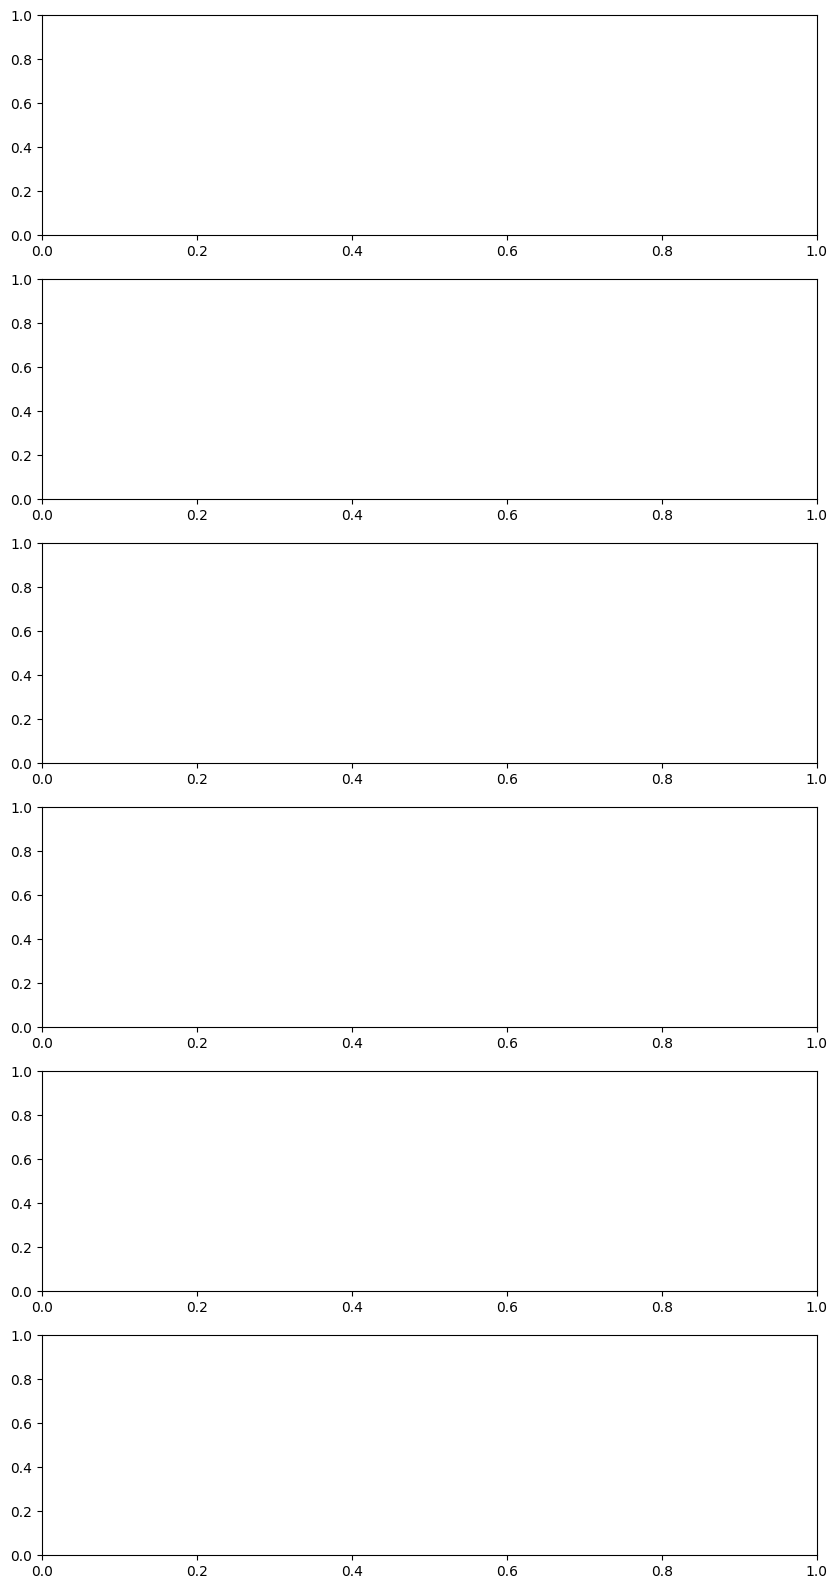

In [8]:
sampled_video_indices=list(range(0,len(videos),4))
_, ax=plt.subplots(len(sampled_video_indices),1, figsize=(10,20))
for i, b in enumerate(sampled_video_indices): 
    label_ids=torch.nonzero(labels[b]>0, as_tuple=True)[0].tolist()
    break
b, label_ids

In [ ]:

_, ax=plt.subplots(2*video.shape[0],1, figsize=(10,20))
for b in range(video.shape[0]): 
    label_ids=torch.nonzero(label[b]>0, as_tuple=True)[0].tolist()
    class_names=[class_ids[l] for l in label_ids]
    ax[2*b].imshow(make_grid(original_videos[b].permute(1,0,2,3)).permute(1,2,0))
    ax[2*b].axis('off')
    ax[2*b].set_title('-'.join(class_names), fontsize=12)
    ax[2*b+1].imshow(make_grid(video[b].permute(1,0,2,3)).permute(1,2,0))
    ax[2*b+1].axis('off')
    # ax[2*b+1].set_title('-'.join(class_names), fontsize=12)
plt.tight_layout()